In [118]:
# This notebook is to plot the conditions for forks
# There are two conditions saved in the file and they both have to be zero
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [119]:
fdir1 = "output/r=3.000000phi= 0.000000/cond1-ldos.tsv"
df1 = pd.read_csv(fdir1, sep="\t", header=None, dtype=np.double, skiprows=3)
head1 = pd.read_csv(fdir1, sep="\t", nrows=1)

fdir2 = "output/r=3.000000phi= 0.000000/cond2-ldos.tsv"
df2 = pd.read_csv(fdir2, sep="\t", header=None, dtype=np.double, skiprows=3)
head2 = pd.read_csv(fdir2, sep="\t", nrows=1)

fdir3 = "output/r=3.000000phi= 0.000000/condensed-ldos.tsv"
df3 = pd.read_csv(fdir3, sep="\t", header=None, dtype=np.double, skiprows=3)
head3 = pd.read_csv(fdir3, sep="\t", nrows=1)

nx, ny, dx, dy, sx, sy, sep, crcR, crcPhi, sKx, sKy = head1.iloc[0].tolist()

In [120]:
Z = df1.to_numpy()
Z2 = df2.to_numpy()
Z3 = df3.to_numpy()
xlin = np.linspace(-sx, sx, int(nx))
ylin = np.linspace(-sy, sy, int(ny))
X, Y = np.meshgrid(xlin, ylin)

In [121]:
# Apply Mapping
def compress(beta, z):
    return np.abs(np.tanh(beta * z))


Zc = compress(1e4, Z)
Zc2 = compress(1e3, Z2)

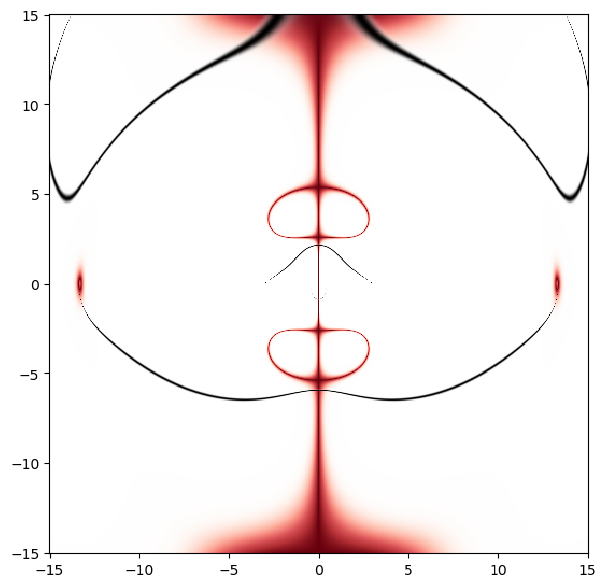

In [122]:
fig1, ax1 = plt.subplots(figsize=(7, 7))

ax1.pcolormesh(X, Y, Zc, cmap="Reds_r", alpha=(1-Zc))
ax1.pcolormesh(X, Y, Zc2, cmap="Greys_r", alpha=(1-Zc2))
#ax1.pcolormesh(X, Y, np.abs(Zc2), cmap="Greys_r", alpha=0.5)
ax1.set_aspect("equal")

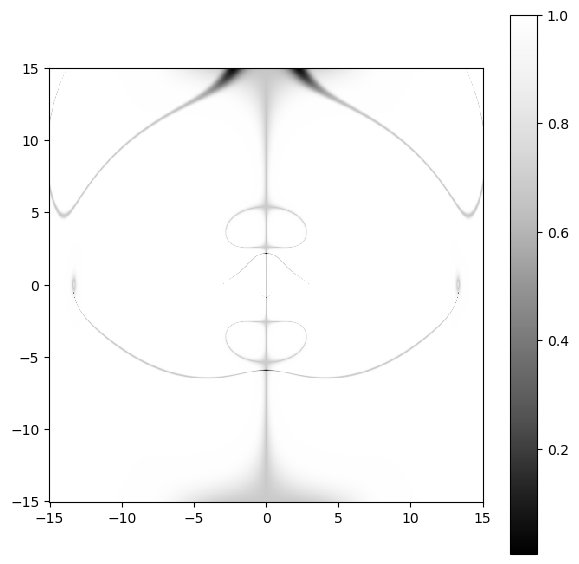

In [123]:
fig2, ax2 = plt.subplots(figsize=(7, 7))

ZT = 0.5 * Zc + 0.5 * Zc2

pc = ax2.pcolormesh(X, Y, ZT, cmap="Greys_r", alpha=(1-ZT))
cb = fig2.colorbar(pc, ax=ax2)
#ax1.pcolormesh(X, Y, np.abs(Zc2), cmap="Greys_r", alpha=0.5)
ax2.set_aspect("equal")

In [124]:
Zm = np.ma.masked_outside(ZT, 0, 0.2)

In [125]:
np.max(Zm)

np.float64(0.1995691597172609)

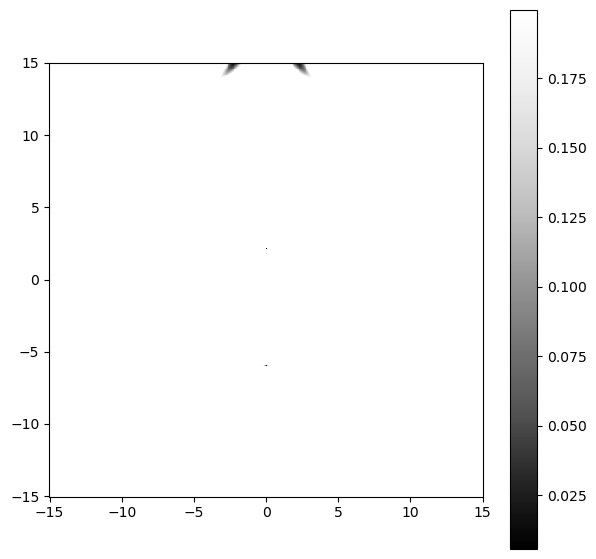

In [126]:
fig3, ax3 = plt.subplots(figsize=(7, 7))

pc = ax3.pcolormesh(X, Y, Zm, cmap="Greys_r")
cb = fig3.colorbar(pc, ax=ax3)
#ax1.pcolormesh(X, Y, np.abs(Zc2), cmap="Greys_r", alpha=0.5)
ax3.set_aspect("equal")

In [127]:
# Dot Finding Routine
from scipy import ndimage

binary = 1 - Zm.mask.astype(int)
labels, num = ndimage.label(binary)
centroids = ndimage.center_of_mass(binary, labels, range(1, num+1))
points = [(X[int(r), int(c)], Y[int(r), int(c)]) for r, c in centroids]

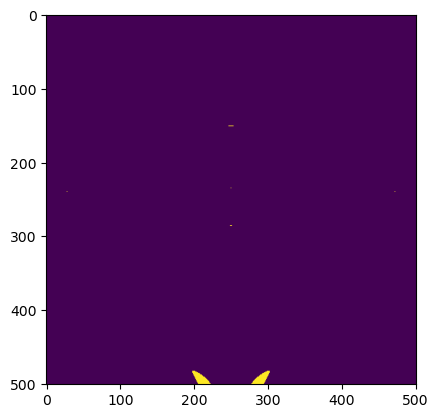

In [128]:
plt.imshow(binary)

In [129]:
points[0]

(np.float64(0.0), np.float64(-5.9399999999999995))

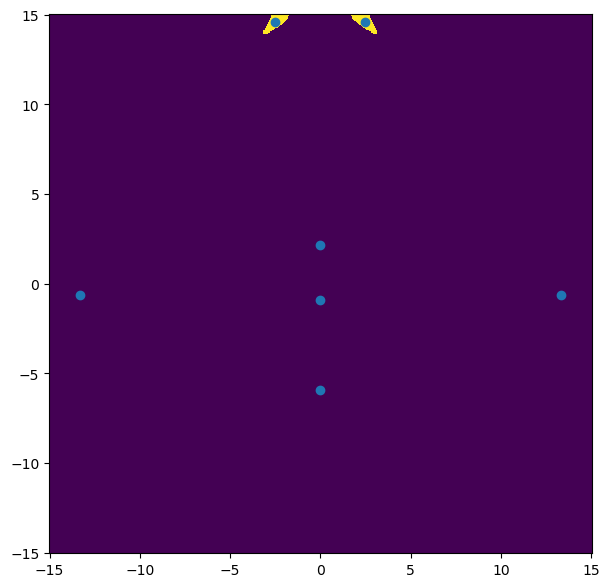

In [130]:
fig4, ax4 = plt.subplots(figsize=(7, 7))

ax4.pcolormesh(X, Y, binary)

rows, cols = np.array(centroids).T

x_pts = X[rows.astype(int), cols.astype(int)]
y_pts = Y[rows.astype(int), cols.astype(int)]

ax4.scatter(x_pts, y_pts)

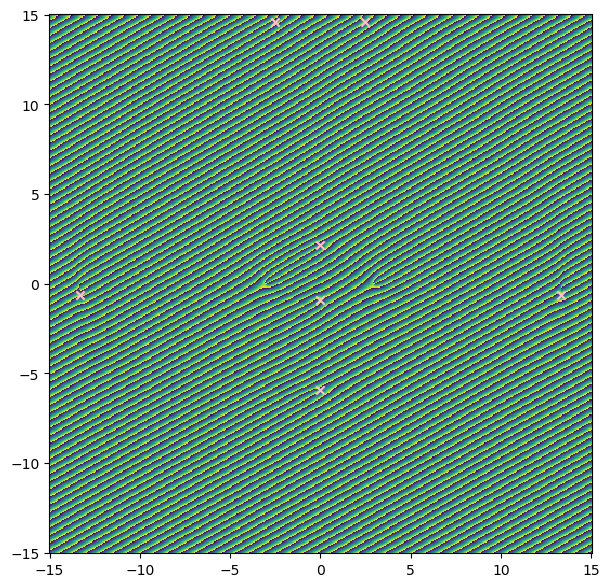

In [131]:
fig5, ax5 = plt.subplots(figsize=(7, 7))

ax5.pcolormesh(X, Y, Z3)
ax5.scatter(x_pts, y_pts, marker="x", c="pink")

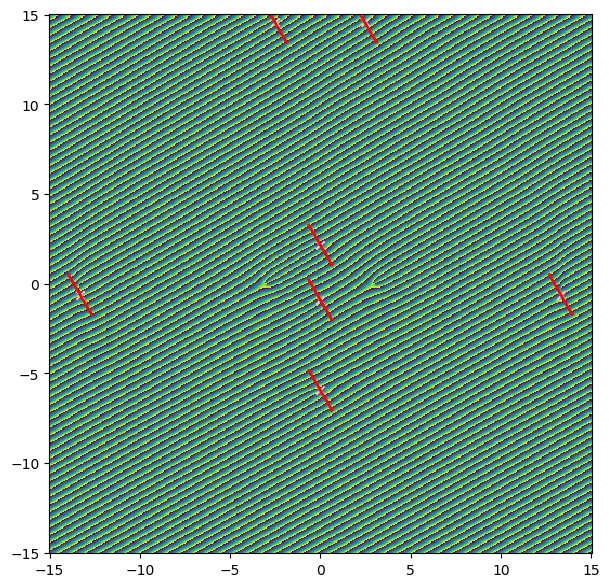

In [142]:
from matplotlib.collections import LineCollection

mK = sKy/sKx # slop of line
thetK = np.arctan2(sKy, sKx)
kstep = 0.5 *  1/(2*np.pi) * np.sqrt(sKx ** 2 + sKy ** 2) # width

segments = []

for i in range(0, len(x_pts)):
    deltax = kstep * np.cos(thetK)
    deltay = kstep * np.sin(thetK)

    x0 = x_pts[i] - deltax
    y0 = y_pts[i] - deltay
    xf = x_pts[i] + deltax
    yf = y_pts[i] + deltay

    segments.append([(x0, y0), (xf, yf)])

lc = LineCollection(segments, colors="r", linewidths=2)

fig6, ax6 = plt.subplots(figsize=(7, 7))

ax6.pcolormesh(X, Y, Z3)
ax6.scatter(x_pts, y_pts, marker="x", c="pink")
ax6.add_collection(lc)

In [148]:
segments[0]

[(np.float64(0.677644346273664), np.float64(-7.113712001072646)),
 (np.float64(-0.677644346273664), np.float64(-4.766287998927353))]

In [157]:
# Interpolating and calculating phase
N = 1000
tspace = np.linspace(0, 1, N)

x0, y0 = segments[0][0]
xf, yf = segments[0][1]

x = x0 + tspace*(xf - x0)
y = y0 + tspace*(yf - y0)

from scipy.interpolate import RegularGridInterpolator

interp_phi = RegularGridInterpolator((Y[:, 0], X[0,:]), Z3)

phi_line = interp_phi(np.column_stack([y, x]))
phi_line_un = np.unwrap(phi_line)
total_phase = phi_line_un[-1] - phi_line_un[0]
print(total_phase)

1.1686870452249638
